In [1]:
# =========================
# CELL 1 — IMPORTS + CONFIG
# =========================
from google.colab import drive
drive.mount('/content/drive')

import os
import json
import random
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# =========================
# PATH CONFIG
# =========================
PREPROCESSED_DIR = "/content/drive/MyDrive/S-Class/Orion/OrionFL/APTOS_2019/preprocessed"
PROJECT_DIR = "/content/drive/MyDrive/S-Class/Orion/OrionFL/orion-fl-dr-research"

EDA_DIR = os.path.join(PROJECT_DIR, "results", "eda", "aptos")
FIGURES_DIR = os.path.join(EDA_DIR, "figures")
LOGS_DIR = os.path.join(EDA_DIR, "logs")

os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(LOGS_DIR, exist_ok=True)

NPZ_FILENAME = "orion_dr_224.npz"
NPZ_PATH = os.path.join(PREPROCESSED_DIR, NPZ_FILENAME)

print("PREPROCESSED_DIR:", PREPROCESSED_DIR)
print("PREPROCESSED_DIR exists:", os.path.exists(PREPROCESSED_DIR))
print("PROJECT_DIR:", PROJECT_DIR)
print("PROJECT_DIR exists:", os.path.exists(PROJECT_DIR))
print("EDA_DIR:", EDA_DIR)
print("NPZ_PATH:", NPZ_PATH)
print("NPZ exists:", os.path.exists(NPZ_PATH))

Mounted at /content/drive
PREPROCESSED_DIR: /content/drive/MyDrive/S-Class/Orion/OrionFL/APTOS_2019/preprocessed
PREPROCESSED_DIR exists: True
PROJECT_DIR: /content/drive/MyDrive/S-Class/Orion/OrionFL/orion-fl-dr-research
PROJECT_DIR exists: True
EDA_DIR: /content/drive/MyDrive/S-Class/Orion/OrionFL/orion-fl-dr-research/results/eda/aptos
NPZ_PATH: /content/drive/MyDrive/S-Class/Orion/OrionFL/APTOS_2019/preprocessed/orion_dr_224.npz
NPZ exists: True


In [2]:
# =========================
# CELL 2 — CHECK DIRECTORY CONTENT
# =========================
if os.path.exists(PREPROCESSED_DIR):
    print("Files inside PREPROCESSED_DIR:")
    for f in os.listdir(PREPROCESSED_DIR):
        print("-", f)
else:
    print("PREPROCESSED_DIR not found.")

Files inside PREPROCESSED_DIR:
- orion_dr_224.npz
- best_mobilenetv2_stage1.keras
- best_mobilenetv2_finetune.keras
- mobilenetv2_aptos_final.keras
- mobilenetv2_run_info.json
- output


In [3]:
# =========================
# CELL 3 — SANITY CHECK NPZ
# =========================
assert os.path.exists(NPZ_PATH), f"NPZ file tidak ditemukan: {NPZ_PATH}"

data = np.load(NPZ_PATH, allow_pickle=True)
print("Keys in NPZ:", data.files)

for k in data.files:
    arr = data[k]
    try:
        print(f"{k}: shape={arr.shape}, dtype={arr.dtype}")
    except:
        print(f"{k}: type={type(arr)}")

Keys in NPZ: ['images', 'labels']
images: shape=(3662, 224, 224, 3), dtype=uint8
labels: shape=(3662,), dtype=int64


In [4]:
# =========================
# CELL 4 — LOAD DATA
# =========================
X = data["images"]
y = data["labels"]

print("X shape:", X.shape)
print("y shape:", y.shape)
print("X dtype:", X.dtype)
print("y dtype:", y.dtype)

print("\nExample labels:", y[:20])

X shape: (3662, 224, 224, 3)
y shape: (3662,)
X dtype: uint8
y dtype: int64

Example labels: [2 4 1 0 0 4 0 2 2 1 0 2 0 3 1 0 2 0 0 2]


In [5]:
# =========================
# CELL 5 — BASIC DATASET SUMMARY
# =========================
num_samples = len(X)
image_shape = X.shape[1:]
num_classes = len(np.unique(y))

summary = {
    "npz_path": NPZ_PATH,
    "num_samples": int(num_samples),
    "image_shape": tuple(int(v) for v in image_shape),
    "x_dtype": str(X.dtype),
    "y_dtype": str(y.dtype),
    "num_classes": int(num_classes),
    "label_min": int(np.min(y)),
    "label_max": int(np.max(y))
}

print(json.dumps(summary, indent=4))

{
    "npz_path": "/content/drive/MyDrive/S-Class/Orion/OrionFL/APTOS_2019/preprocessed/orion_dr_224.npz",
    "num_samples": 3662,
    "image_shape": [
        224,
        224,
        3
    ],
    "x_dtype": "uint8",
    "y_dtype": "int64",
    "num_classes": 5,
    "label_min": 0,
    "label_max": 4
}


   label  count  percentage
0      0   1805   49.290005
1      1    370   10.103768
2      2    999   27.280175
3      3    193    5.270344
4      4    295    8.055707


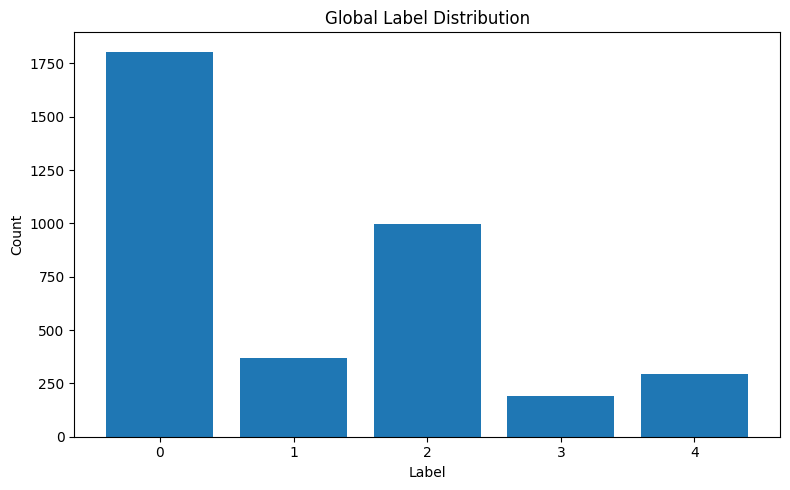

Saved: /content/drive/MyDrive/S-Class/Orion/OrionFL/orion-fl-dr-research/results/eda/aptos/figures/global_label_distribution.png


In [6]:
# =========================
# CELL 6 — LABEL DISTRIBUTION
# =========================
label_counts = pd.Series(y).value_counts().sort_index()
label_df = pd.DataFrame({
    "label": label_counts.index,
    "count": label_counts.values,
    "percentage": (label_counts.values / len(y)) * 100
})

print(label_df)

plt.figure(figsize=(8, 5))
plt.bar(label_df["label"].astype(str), label_df["count"])
plt.title("Global Label Distribution")
plt.xlabel("Label")
plt.ylabel("Count")
plt.tight_layout()

label_dist_path = os.path.join(FIGURES_DIR, "global_label_distribution.png")
plt.savefig(label_dist_path, dpi=300, bbox_inches="tight")
plt.show()
plt.close()

print("Saved:", label_dist_path)

In [7]:
# =========================
# CELL 7 — PIXEL STATISTICS
# =========================
print("Pixel min :", X.min())
print("Pixel max :", X.max())
print("Pixel mean:", float(X.mean()))
print("Pixel std :", float(X.std()))

Pixel min : 0
Pixel max : 255
Pixel mean: 60.22978920317359
Pixel std : 59.27930454149542


In [8]:
# =========================
# CELL 8 — IMAGE SHAPE CHECK
# =========================
unique_shapes = set()

for i in range(min(len(X), 100)):
    unique_shapes.add(X[i].shape)

print("Unique shapes found in first 100 samples:")
for s in unique_shapes:
    print("-", s)

Unique shapes found in first 100 samples:
- (224, 224, 3)


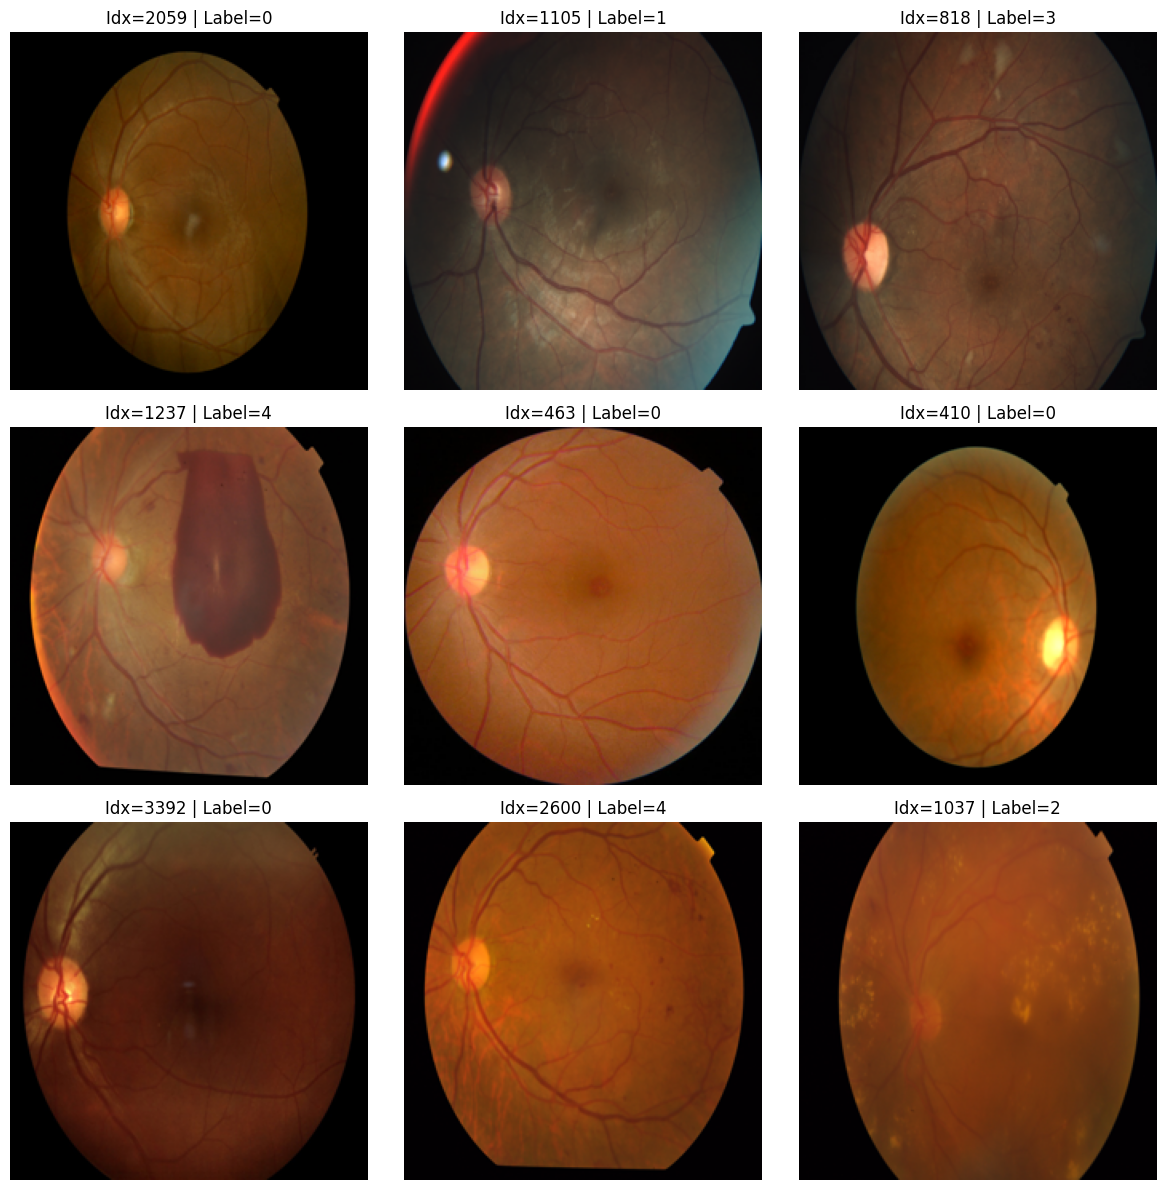

Saved: /content/drive/MyDrive/S-Class/Orion/OrionFL/orion-fl-dr-research/results/eda/aptos/figures/sample_random_grid.png


In [9]:
# =========================
# CELL 9 — SAMPLE IMAGE GRID (RANDOM)
# =========================
n_samples = 9
indices = np.random.choice(len(X), size=n_samples, replace=False)

plt.figure(figsize=(12, 12))
for i, idx in enumerate(indices):
    plt.subplot(3, 3, i + 1)
    img = X[idx]

    if img.dtype != np.uint8:
        img_to_show = img.astype(np.uint8) if img.max() > 1 else (img * 255).astype(np.uint8)
    else:
        img_to_show = img

    plt.imshow(img_to_show)
    plt.title(f"Idx={idx} | Label={y[idx]}")
    plt.axis("off")

plt.tight_layout()
sample_random_path = os.path.join(FIGURES_DIR, "sample_random_grid.png")
plt.savefig(sample_random_path, dpi=300, bbox_inches="tight")
plt.show()
plt.close()

print("Saved:", sample_random_path)

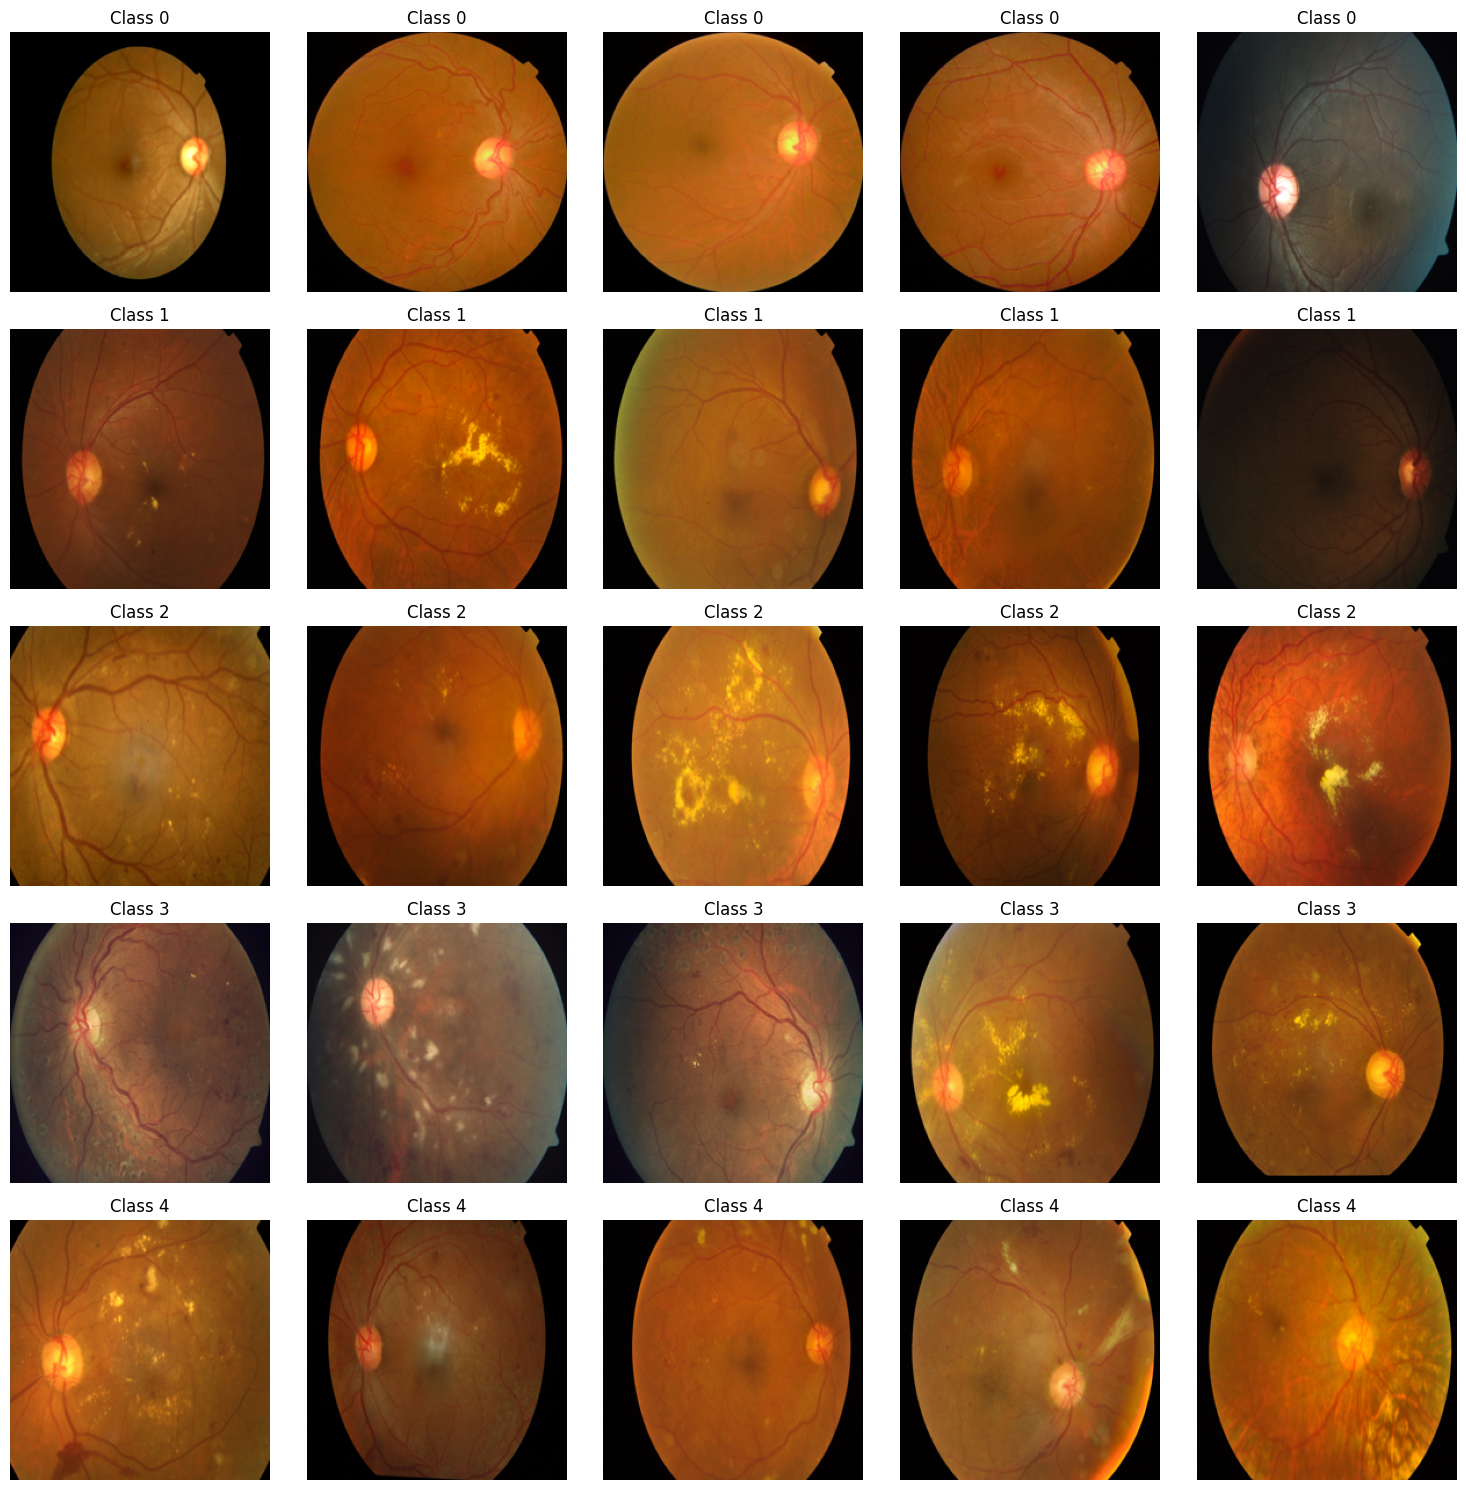

Saved: /content/drive/MyDrive/S-Class/Orion/OrionFL/orion-fl-dr-research/results/eda/aptos/figures/sample_per_class.png


In [10]:
# =========================
# CELL 10 — SAMPLE IMAGE PER CLASS
# =========================
unique_labels = sorted(np.unique(y))

fig, axes = plt.subplots(len(unique_labels), 5, figsize=(15, 3 * len(unique_labels)))

for row, label in enumerate(unique_labels):
    class_indices = np.where(y == label)[0]
    chosen = np.random.choice(class_indices, size=min(5, len(class_indices)), replace=False)

    for col in range(5):
        ax = axes[row, col] if len(unique_labels) > 1 else axes[col]
        ax.axis("off")

        if col < len(chosen):
            img = X[chosen[col]]

            if img.dtype != np.uint8:
                img_to_show = img.astype(np.uint8) if img.max() > 1 else (img * 255).astype(np.uint8)
            else:
                img_to_show = img

            ax.imshow(img_to_show)
            ax.set_title(f"Class {label}")

plt.tight_layout()
sample_per_class_path = os.path.join(FIGURES_DIR, "sample_per_class.png")
plt.savefig(sample_per_class_path, dpi=300, bbox_inches="tight")
plt.show()
plt.close()

print("Saved:", sample_per_class_path)

In [11]:
# =========================
# CELL 11 — GLOBAL TRAIN/VAL SPLIT (80:20)
# =========================
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=SEED,
    stratify=y
)

print("Train shape:", X_train.shape, y_train.shape)
print("Val shape  :", X_val.shape, y_val.shape)

Train shape: (2929, 224, 224, 3) (2929,)
Val shape  : (733, 224, 224, 3) (733,)


In [12]:
# =========================
# CELL 12 — TRAIN/VAL LABEL DISTRIBUTION
# =========================
train_counts = pd.Series(y_train).value_counts().sort_index()
val_counts = pd.Series(y_val).value_counts().sort_index()

split_df = pd.DataFrame({
    "train_count": train_counts,
    "val_count": val_counts
}).fillna(0).astype(int)

split_df["train_pct"] = split_df["train_count"] / len(y_train) * 100
split_df["val_pct"] = split_df["val_count"] / len(y_val) * 100

print(split_df)

   train_count  val_count  train_pct    val_pct
0         1444        361  49.300102  49.249659
1          296         74  10.105838  10.095498
2          799        200  27.278935  27.285130
3          154         39   5.257767   5.320600
4          236         59   8.057357   8.049113


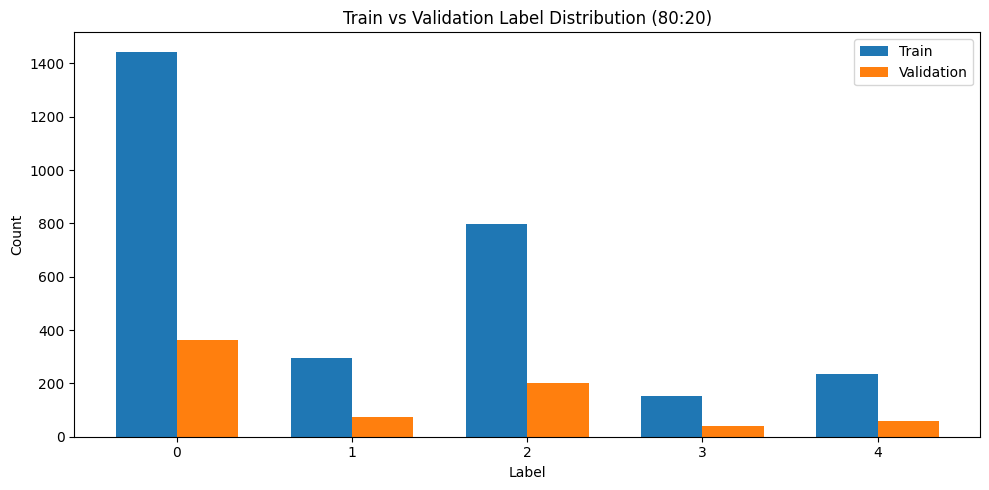

Saved: /content/drive/MyDrive/S-Class/Orion/OrionFL/orion-fl-dr-research/results/eda/aptos/figures/train_val_label_distribution.png


In [13]:
# =========================
# CELL 13 — VISUALIZE TRAIN/VAL DISTRIBUTION
# =========================
labels = split_df.index.astype(str)

x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(10, 5))
plt.bar(x - width/2, split_df["train_count"], width=width, label="Train")
plt.bar(x + width/2, split_df["val_count"], width=width, label="Validation")

plt.xticks(x, labels)
plt.xlabel("Label")
plt.ylabel("Count")
plt.title("Train vs Validation Label Distribution (80:20)")
plt.legend()
plt.tight_layout()

split_dist_path = os.path.join(FIGURES_DIR, "train_val_label_distribution.png")
plt.savefig(split_dist_path, dpi=300, bbox_inches="tight")
plt.show()
plt.close()

print("Saved:", split_dist_path)

In [14]:
# =========================
# CELL 14 — CHECK FOR NaN / INF
# =========================
print("Any NaN in X:", np.isnan(X).any())
print("Any Inf in X:", np.isinf(X).any())
print("Any NaN in y:", np.isnan(y).any() if np.issubdtype(y.dtype, np.number) else False)

Any NaN in X: False
Any Inf in X: False
Any NaN in y: False


In [15]:
# =========================
# CELL 15 — OPTIONAL DUPLICATE CHECK (LIGHTWEIGHT)
# =========================
sample_check_size = min(1000, len(X))
sample_flat = X[:sample_check_size].reshape(sample_check_size, -1)

sample_hashes = [hash(arr.tobytes()) for arr in sample_flat]
unique_hashes = len(set(sample_hashes))

print(f"Checked first {sample_check_size} samples")
print("Unique hashes:", unique_hashes)
print("Potential duplicates:", sample_check_size - unique_hashes)

Checked first 1000 samples
Unique hashes: 986
Potential duplicates: 14


In [16]:
# =========================
# CELL 16 — SAVE EDA SUMMARY JSON
# =========================
eda_summary = {
    "npz_path": NPZ_PATH,
    "num_samples": int(len(X)),
    "image_shape": tuple(int(v) for v in X.shape[1:]),
    "x_dtype": str(X.dtype),
    "y_dtype": str(y.dtype),
    "num_classes": int(len(np.unique(y))),
    "global_label_distribution": {str(int(k)): int(v) for k, v in label_counts.to_dict().items()},
    "train_size": int(len(X_train)),
    "val_size": int(len(X_val)),
    "train_ratio": 0.8,
    "val_ratio": 0.2,
    "train_label_distribution": {str(int(k)): int(v) for k, v in train_counts.to_dict().items()},
    "val_label_distribution": {str(int(k)): int(v) for k, v in val_counts.to_dict().items()},
    "pixel_min": float(X.min()),
    "pixel_max": float(X.max()),
    "pixel_mean": float(X.mean()),
    "pixel_std": float(X.std())
}

eda_summary_path = os.path.join(LOGS_DIR, "eda_summary.json")
with open(eda_summary_path, "w") as f:
    json.dump(eda_summary, f, indent=4)

print("Saved:", eda_summary_path)

Saved: /content/drive/MyDrive/S-Class/Orion/OrionFL/orion-fl-dr-research/results/eda/aptos/logs/eda_summary.json


In [17]:
# =========================
# CELL 17 — QUICK SUMMARY PRINT
# =========================
with open(os.path.join(LOGS_DIR, "eda_summary.json"), "r") as f:
    summary = json.load(f)

print(json.dumps(summary, indent=4))

{
    "npz_path": "/content/drive/MyDrive/S-Class/Orion/OrionFL/APTOS_2019/preprocessed/orion_dr_224.npz",
    "num_samples": 3662,
    "image_shape": [
        224,
        224,
        3
    ],
    "x_dtype": "uint8",
    "y_dtype": "int64",
    "num_classes": 5,
    "global_label_distribution": {
        "0": 1805,
        "1": 370,
        "2": 999,
        "3": 193,
        "4": 295
    },
    "train_size": 2929,
    "val_size": 733,
    "train_ratio": 0.8,
    "val_ratio": 0.2,
    "train_label_distribution": {
        "0": 1444,
        "1": 296,
        "2": 799,
        "3": 154,
        "4": 236
    },
    "val_label_distribution": {
        "0": 361,
        "1": 74,
        "2": 200,
        "3": 39,
        "4": 59
    },
    "pixel_min": 0.0,
    "pixel_max": 255.0,
    "pixel_mean": 60.22978920317359,
    "pixel_std": 59.27930454149542
}
